# Principal Component Analysis (PCA)

### Objective

This notebook explores Principal Component Analysis (PCA) using the Wisconsin Diagnostic Breast Cancer (WDBC) dataset, as previously explored in both 02_logistic_regression and 05_classification_metrics.

### Research Question

Can we reduce the number of features in the WDBC dataset while retaining most of the information?

### Learning Objectives

- Understand why dimensionality reduction is useful
- Standardise data before applying PCA
- Apply PCA to a dataset
- Examine explained variance
- Visualise data using principal components

## 01. Why PCA?

The WDBC dataset contains 30 numerical features describing characteristics of cell nuclei. Using all 30 features can make a dataset more difficult to visualise and may introduce redundancy when features are correlated.

PCA transforms the original features into a smaller set of principal components while attempting to retain as much variation in the data as possible. This allows us to represent high-dimensional data using fewer dimensions.

## 02. Prepare the Data

PCA is applied to numerical features, so the diagnosis column will not be included in PCA's calculations. We will also remove the 'id' and 'Unnamed: 32' columns as these do not represent useful predictive features

In [ ]:
#import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Modules Imported")

#Load WDBC dataset, remove unnecessary columns, map diagnosis to 0/1.
df = pd.read_csv('/Users/hweeenheah/Downloads/EDA_Resources/machine-learning-foundations/02_Logistic Regression/wdbc.csv')
df = df.drop(columns=['id', 'Unnamed: 32'])
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
df.head()

#Separate features from target 
#X contains 30 numerical features (w/o dx), used for PCA calculations
X = df.drop(columns=['diagnosis'])
#y contains diagnosis, retained to cross reference later
y = df['diagnosis']

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Modules Imported
Number of features: 30
Number of samples: 569


## 03. Scaling the Features

The features in the WDBC dataset have different numerical scales. For example, some features such as area have a much larger numerical value than other features such as smoothness.

PCA is sensitive to the scale of the features. Therefore we scale the features so that each feature has a mean of 0 and a standard deviation of 1. This standardisation ensures that features are on a comparable scale before applying PCA.

In [7]:
#import modules
from sklearn.preprocessing import StandardScaler

#standardise X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Standardisation complete")

#check that mean is close to 0.0, and sd is close to 1.0
print("Mean:", X_scaled.mean())
print("Standard Deviation:", X_scaled.std())

X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled.head()

Standardisation complete
Mean: -6.53516165871914e-17
Standard Deviation: 1.0


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


## 04. Apply PCA

PCA transforms the 30 original features into a new set of principal components. Each principal component is a combination of the original features. 

The first principal component (PC) captures the greatest amount of variation in the data, the second PC captures the greatest remaining variation, and so on.

For now, we will calculate all 30 PCs so that we can examine how much variation each component explains.

In [10]:
#import pca
from sklearn.decomposition import PCA

#create pca model, then fit (pca learn about 30 features) & transform (pca transform 30 features into 30 new PCs)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("Original number of features:", X_scaled.shape[1])
print("Number of principal components:", X_pca.shape[1])

Original number of features: 30
Number of principal components: 30


## 05. Explained Variance 

Each principal component captures a certain amount of variation in the original dataset. The explained variance ratio tells us the proportion of total variance captured by each principal component. The first principal component explains the most variance, followed by the second PC, and so on. 

### 5.1 Scree Plot

A scree plot shows the proportion of variance explained by each principal component. The components are ordered from the most variance explained, to the least. We can use the plot to identify where additional components begin to contribute relatively little additional variance.

PC1: 0.4427
PC2: 0.1897
PC3: 0.0939
PC4: 0.0660
PC5: 0.0550
PC6: 0.0402
PC7: 0.0225
PC8: 0.0159
PC9: 0.0139
PC10: 0.0117
PC11: 0.0098
PC12: 0.0087
PC13: 0.0080
PC14: 0.0052
PC15: 0.0031
PC16: 0.0027
PC17: 0.0020
PC18: 0.0018
PC19: 0.0016
PC20: 0.0010
PC21: 0.0010
PC22: 0.0009
PC23: 0.0008
PC24: 0.0006
PC25: 0.0005
PC26: 0.0003
PC27: 0.0002
PC28: 0.0001
PC29: 0.0000
PC30: 0.0000


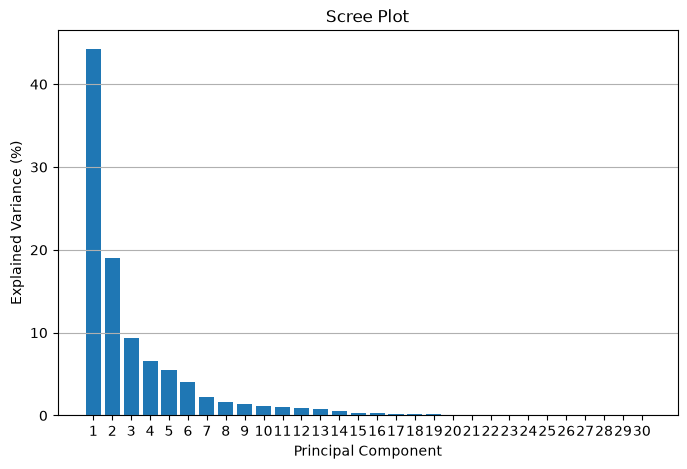

In [32]:
#explained variance of each PC
explained_variance = pca.explained_variance_ratio_
for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

#scree plot
plt.figure(figsize=(8,5))
plt.bar(range(1,len(explained_variance) + 1), explained_variance * 100)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('Scree Plot')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(axis='y')
plt.show()

### 5.2 Cumulative Explained Variance

The cumulative explained variance shows how much of total variance is explained as we add more principal components. This helps us decide how many principal components to keep when reducing the dimensionality of the dataset.

PC1: 0.4427
PC2: 0.6324
PC3: 0.7264
PC4: 0.7924
PC5: 0.8473
PC6: 0.8876
PC7: 0.9101
PC8: 0.9260
PC9: 0.9399
PC10: 0.9516
PC11: 0.9614
PC12: 0.9701
PC13: 0.9781
PC14: 0.9834
PC15: 0.9865
PC16: 0.9892
PC17: 0.9911
PC18: 0.9929
PC19: 0.9945
PC20: 0.9956
PC21: 0.9966
PC22: 0.9975
PC23: 0.9983
PC24: 0.9989
PC25: 0.9994
PC26: 0.9997
PC27: 0.9999
PC28: 1.0000
PC29: 1.0000
PC30: 1.0000


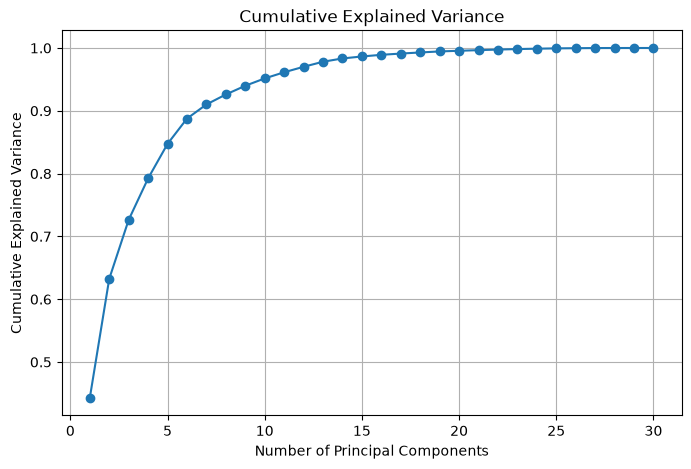

In [33]:
#cumulative explained variance (PC(n) = PC1+PC2...+PC(n))
cumulative_variance = np.cumsum(explained_variance)
for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

#line chart of cumulative explained variance
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.grid()
plt.show()

In [39]:
#check how many components explained (threshold%) of variance
for i, variance in enumerate(cumulative_variance, start=1):
    if variance >= 0.95:
        print(f"{i} components explain {variance:.2%} of the variance")
        break

10 components explain 95.16% of the variance


## 06. Reduce the Dimensions

 There is no universal threshold for explained variance. A target such as 80%, 90%, 95% or 99% may be chosen depending on the purpose of the dimensionality reduction and the acceptable loss of information. For this notebook, we will use 95% as the target as a suitable trade off between explaining most variance, yet being able to reduce dimensionality sufficiently.

 The cumulative explained variance shows that the first 10 principal components captured approximately 95% of the variance in the original dataset. We can thus reduce the dataset from the 30 original features to 10 principal components while retaining most of the variation in the data.

In [41]:
#Create PCA model with first 10 PCs
pca_10 = PCA(n_components=10)
#fit(learn all 30 features) & transform (convert into 10 PCs)
X_pca_10 = pca_10.fit_transform(X_scaled)
print("Original number of features:", X.shape[1])
print("Reduced number of components:", X_pca_10.shape[1])

Original number of features: 30
Reduced number of components: 10


## 07. Interpret Principal Components

Principal Components are combinations of the original features. To understand what contributes to each PC, we examine the loadings. A loading represents the contribution of an original feature to a PC. Large absolute loadings indicate that a feature contributes strongly to that PC, and may greatly influence the interpretation, direction, and variance of that PC. 

In [67]:
#generate eigenvector
loadings = pd.DataFrame(pca_10.components_.T, columns=[f'PC{i}' for i in range(1, 11)], index=X.columns)
loadings.head()

#focus on pc1 loadings
pc1_loadings = loadings['PC1'].sort_values(key=abs, ascending=False)
print(pc1_loadings.head())

#focus on pc2 loadings
pc2_loadings = loadings['PC2'].sort_values(key=abs, ascending=False)
print(pc2_loadings.head())

concave points_mean     0.260854
concavity_mean          0.258400
concave points_worst    0.250886
compactness_mean        0.239285
perimeter_worst         0.236640
Name: PC1, dtype: float64
fractal_dimension_mean     0.366575
fractal_dimension_se       0.280092
fractal_dimension_worst    0.275339
radius_mean               -0.233857
compactness_se             0.232716
Name: PC2, dtype: float64


## 08. Visualise the Principal Components

Although PCA does not use the diagnosis when creating the principal components, we can use the diagnosis labels afterwards to see how the samples are distributed. 

The first two principal components provide a 2D representation of the original 30-feature dataset. We can visualise these components and colour the samples according to their actual diagnosis.

We will plot PC1 against PC2, with benign and malignant colour-coded. This will show us whether the PCA-transformed data naturally shows any separation between the 2 diagnoses. 

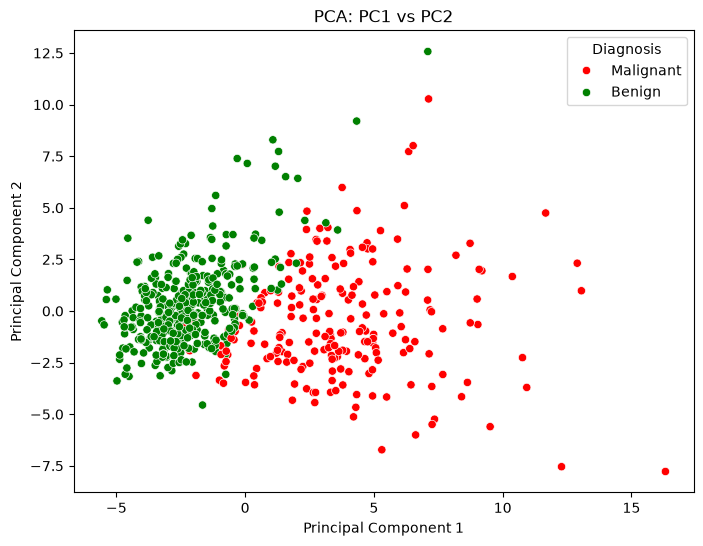

In [63]:
#convert X_pca_10 from numpy array to df
pca_df = pd.DataFrame(X_pca_10, columns=[f'PC{i}' for i in range(1, 11)])
#add dx back into df
pca_df['diagnosis'] = y.values
pca_df.head()

#rename dx values back
pca_df['diagnosis'] = pca_df['diagnosis'].map({0: 'Benign', 1: 'Malignant'})
#plot PC1 vs PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df,x='PC1',y='PC2',hue='diagnosis', palette={'Benign': 'green', 'Malignant': 'red'})
plt.title('PCA: PC1 vs PC2')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Diagnosis')
plt.show()

The first two PCs provide a 2D representation of the original 30-feature dataset. The plot shows that benign and malignant samples form relatively distinct groups, although there is some overlaps present. This suggests that much of the variation captured by PCA is associated with differences between the 2 diagnoses.

## 09. Key takeaways

PCA reduces the dimensionality of a dataset by transforming the original features in principal components (PCs). 

- PCA is unsupervised and does not use the target variable when creating the PCs.
- Features should be standardised before applying PCA when they are on different scales.
- The first PC captures the greatest amount of variance, followed by subsequent PCs, and so on. 
- Explained variance helps determine how many PCs to retain.
- In this dataset, 10 PCs captures approximately 95% of the variance, reducing the number of dimensions from 30 to 10. 
- PCA can also help visualise high-dimensional data by projecting it into 2 or 3 PCs 

In this example, the diagnosis labels were kept separate from PCA and only used afterwards to visualise how benign and malignant samples were distributed in the PCA space.